In [1]:
import torch
import numpy as np
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [2]:
import pandas as pd

# Load XRP CSV
xrp_df = pd.read_csv(r'feature_datasets\XRP_features.csv', parse_dates=True, index_col=0)

# Define X and y
xrp_y = xrp_df['Close'].shift(-1)          # next-day close price
xrp_X = xrp_df.drop(columns=['Close'])     # all other features

# Drop last row (y will be NaN)
xrp_X = xrp_X.iloc[:-1]
xrp_y = xrp_y.iloc[:-1]

# Optional: check shapes
print("XRP X shape:", xrp_X.shape)
print("XRP y shape:", xrp_y.shape)

XRP X shape: (915, 29)
XRP y shape: (915,)


## 70-30 split

In [114]:
# 70% train / 30% test split (time-based)
split_idx = int(len(xrp_X) * 0.7)

xrp_X_train = xrp_X.iloc[:split_idx].values
xrp_X_test  = xrp_X.iloc[split_idx:].values

xrp_y_train = xrp_y.iloc[:split_idx].values
xrp_y_test  = xrp_y.iloc[split_idx:].values

print("XRP X_train shape:", xrp_X_train.shape)
print("XRP X_test shape:", xrp_X_test.shape)
print("XRP y_train shape:", xrp_y_train.shape)
print("XRP y_test shape:", xrp_y_test.shape)

XRP X_train shape: (640, 29)
XRP X_test shape: (275, 29)
XRP y_train shape: (640,)
XRP y_test shape: (275,)


In [115]:
xrp_test_dates = xrp_df.index[-len(xrp_X_test):]

In [116]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Initialize scaler
scaler = MinMaxScaler()

# Fit on TRAIN only
xrp_X_train_scaled = scaler.fit_transform(xrp_X_train)

# Transform TEST using the same scaler
xrp_X_test_scaled = scaler.transform(xrp_X_test)

# Check shapes
print("Scaled X_train shape:", xrp_X_train_scaled.shape)
print("Scaled X_test shape:", xrp_X_test_scaled.shape)

Scaled X_train shape: (640, 29)
Scaled X_test shape: (275, 29)


In [117]:
# Initialize scaler for y
y_scaler = MinMaxScaler()

# Scale training target
xrp_y_train_scaled = y_scaler.fit_transform(xrp_y_train.reshape(-1,1)).flatten()

# Scale test target
xrp_y_test_scaled = y_scaler.transform(xrp_y_test.reshape(-1,1)).flatten()

In [118]:
def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])  # the next day after the sequence
    return np.array(X_seq), np.array(y_seq)

# Create sequences for XRP using scaled target
xrp_X_train_seq, xrp_y_train_seq = create_sequences(xrp_X_train_scaled, xrp_y_train_scaled, time_steps=30)
xrp_X_test_seq, xrp_y_test_seq = create_sequences(xrp_X_test_scaled, xrp_y_test_scaled, time_steps=30)

# Check shapes
print("XRP X_train_seq shape:", xrp_X_train_seq.shape)
print("XRP y_train_seq shape:", xrp_y_train_seq.shape)
print("XRP X_test_seq shape:", xrp_X_test_seq.shape)
print("XRP y_test_seq shape:", xrp_y_test_seq.shape)

XRP X_train_seq shape: (610, 30, 29)
XRP y_train_seq shape: (610,)
XRP X_test_seq shape: (245, 30, 29)
XRP y_test_seq shape: (245,)


### Model training

In [119]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [120]:
# Get number of features from the sequences
input_size = xrp_X_train_seq.shape[2]

# Initialize Bi-LSTM model
model = BiLSTM(input_size=input_size)

In [121]:
model = train_model(model, xrp_X_train_seq, xrp_y_train_seq, epochs=50, batch_size=32, lr=0.001)

Epoch [10/50], Loss: 0.003018
Epoch [20/50], Loss: 0.001828
Epoch [30/50], Loss: 0.002954
Epoch [40/50], Loss: 0.001303
Epoch [50/50], Loss: 0.001621


In [122]:
xrp_preds = predict_model(model, xrp_X_test_seq)

# check
print("Predictions shape:", xrp_preds.shape)
print("First 10 predictions:", xrp_preds[:10])

Predictions shape: (245, 1)
First 10 predictions: [[0.13742314]
 [0.1313352 ]
 [0.12438997]
 [0.11792082]
 [0.11069147]
 [0.1094314 ]
 [0.10558117]
 [0.09817407]
 [0.09437682]
 [0.08297514]]


In [123]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Inverse scale predictions
xrp_preds_actual = y_scaler.inverse_transform(xrp_preds.reshape(-1,1))

# Skip first 30 because of 30-day sequence
xrp_y_test_actual = xrp_y_test[30:].reshape(-1,1)

# Calculate metrics
mse = mean_squared_error(xrp_y_test_actual, xrp_preds_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(xrp_y_test_actual, xrp_preds_actual)
r2 = r2_score(xrp_y_test_actual, xrp_preds_actual)
mape = np.mean(np.abs((xrp_y_test_actual - xrp_preds_actual) / xrp_y_test_actual)) * 100

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MSE: 0.01
RMSE: 0.08
MAE: 0.05
R2 Score: 0.2285
MAPE: 8.18%


In [124]:
xrp_preds_actual = y_scaler.inverse_transform(xrp_preds.reshape(-1,1))

In [125]:
import pandas as pd
import matplotlib.pyplot as plt

# Skip first 30 because of sequence
dates_seq = xrp_df.index[-len(xrp_X_test):][30:]  # test dates aligned with sequences
actual_seq = xrp_y_test[30:]                      # actual prices aligned
pred_seq = xrp_preds_actual                       # predicted prices aligned

# Create DataFrame
df_plot = pd.DataFrame({
    "Date": dates_seq,
    "Actual": actual_seq,
    "Predicted": pred_seq.flatten()
})

df_plot.set_index("Date", inplace=True)
df_plot

,Actual,Predicted
Date,,
2023-05-02,0.464951,0.456689
2023-05-03,0.463494,0.450106
2023-05-04,0.461573,0.442596
2023-05-05,0.467800,0.435600
2023-05-06,0.459549,0.427783
...,...,...
2023-12-28,0.634998,0.475754
2023-12-29,0.623402,0.480926
2023-12-30,0.621844,0.486699


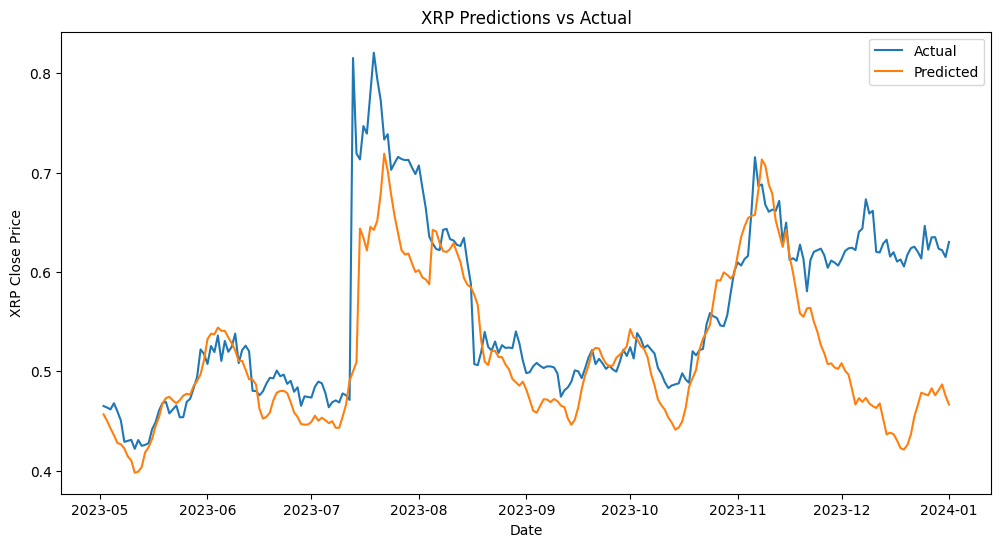

In [126]:
plt.figure(figsize=(12,6))
plt.plot(df_plot["Actual"], label="Actual")
plt.plot(df_plot["Predicted"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("XRP Close Price")
plt.title("XRP Predictions vs Actual")
plt.legend()
plt.show()

## 70% from each year split

In [3]:
# Get unique years from your DataFrame index
years = xrp_df.index.year.unique()
print("Years in dataset:", years)

Years in dataset: Index([2021, 2022, 2023, 2024], dtype='int32', name='Date')


In [4]:
X_train_list = []
y_train_list = []

In [5]:
for year in years:
    # Filter data for this year
    xrp_year = xrp_df[xrp_df.index.year == year]

    # Calculate split index for 70%
    split_idx = int(len(xrp_year) * 0.7)

    # Take first 70% as training
    X_train_year = xrp_year.iloc[:split_idx, 1:].values  # all features except target column
    y_train_year = xrp_year.iloc[:split_idx, 0].values   # target column (e.g., next-day Close)

    # Append to lists
    X_train_list.append(X_train_year)
    y_train_list.append(y_train_year)

    print(f"Year {year}: {len(X_train_year)} train samples")

Year 2021: 129 train samples
Year 2022: 255 train samples
Year 2023: 255 train samples
Year 2024: 0 train samples


In [6]:
import numpy as np

# Stack all years’ train sets
X_train_combined = np.vstack(X_train_list)
y_train_combined = np.hstack(y_train_list)

print("Combined X_train shape:", X_train_combined.shape)
print("Combined y_train shape:", y_train_combined.shape)

Combined X_train shape: (639, 29)
Combined y_train shape: (639,)


In [7]:
X_test_list = []
y_test_list = []

In [8]:
for year in years:
    xrp_year = xrp_df[xrp_df.index.year == year]

    # Calculate split index (same as for train)
    split_idx = max(1, int(len(xrp_year) * 0.7))  # ensures at least 1 sample in train

    # Take the remaining 30% as test
    X_test_year = xrp_year.iloc[split_idx:, 1:].values   # features
    y_test_year = xrp_year.iloc[split_idx:, 0].values    # target

    # Append to test lists
    X_test_list.append(X_test_year)
    y_test_list.append(y_test_year)

    print(f"Year {year}: {len(X_test_year)} test samples")

Year 2021: 56 test samples
Year 2022: 110 test samples
Year 2023: 110 test samples
Year 2024: 0 test samples


In [9]:
import numpy as np

X_test_combined = np.vstack(X_test_list)
y_test_combined = np.hstack(y_test_list)

print("Combined X_test shape:", X_test_combined.shape)
print("Combined y_test shape:", y_test_combined.shape)

Combined X_test shape: (276, 29)
Combined y_test shape: (276,)


In [10]:
from sklearn.preprocessing import MinMaxScaler

# Initialize scalers
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

# Scale training data
X_train_scaled = x_scaler.fit_transform(X_train_combined)
y_train_scaled = y_scaler.fit_transform(y_train_combined.reshape(-1,1)).flatten()

In [11]:
import joblib

joblib.dump(x_scaler,"xrp_x_scaler.pkl")
joblib.dump(y_scaler,"xrp_y_scaler.pkl")

['xrp_y_scaler.pkl']

In [135]:
X_test_scaled = x_scaler.transform(X_test_combined)
y_test_scaled = y_scaler.transform(y_test_combined.reshape(-1,1)).flatten()

print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)
print("Scaled y_train shape:", y_train_scaled.shape)
print("Scaled y_test shape:", y_test_scaled.shape)

Scaled X_train shape: (639, 29)
Scaled X_test shape: (276, 29)
Scaled y_train shape: (639,)
Scaled y_test shape: (276,)


In [136]:
import numpy as np

def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])  # the next day after the sequence
    return np.array(X_seq), np.array(y_seq)

# Create sequences for XRP train and test
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled)
mape = np.mean(np.abs((xrp_y_test_actual - xrp_preds_actual) / xrp_y_test_actual)) * 100
# Check shapes
print("XRP X_train_seq shape:", X_train_seq.shape)
print("XRP y_train_seq shape:", y_train_seq.shape)
print("XRP X_test_seq shape:", X_test_seq.shape)
print("XRP y_test_seq shape:", y_test_seq.shape)

XRP X_train_seq shape: (609, 30, 29)
XRP y_train_seq shape: (609,)
XRP X_test_seq shape: (246, 30, 29)
XRP y_test_seq shape: (246,)


### Model training

In [137]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [138]:
# Get number of features from the sequences
input_size = X_train_seq.shape[2]   # use the combined train sequences

# Initialize Bi-LSTM model for XRP
model_y = BiLSTM(input_size=input_size)

In [139]:
model_y = train_model(model_y, X_train_seq, y_train_seq, epochs=50, batch_size=32, lr=0.001)

c:\Users\tharu\anaconda3\envs\Streamlit\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning:

Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.



Epoch [10/50], Loss: 0.012367
Epoch [20/50], Loss: 0.004565
Epoch [30/50], Loss: 0.001371
Epoch [40/50], Loss: 0.001838
Epoch [50/50], Loss: 0.001188


In [140]:
xrp_preds_ev_year = predict_model(model_y, X_test_seq)
xrp_preds_ev_year[:10]

array([[0.51580036],
       [0.52176756],
       [0.5189928 ],
       [0.52329075],
       [0.54011816],
       [0.5232647 ],
       [0.49972153],
       [0.489056  ],
       [0.46255028],
       [0.46626663]], dtype=float32)

In [141]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict using the trained model
xrp_preds_ev_year = predict_model(model_y, X_test_seq)

# Inverse scale predictions to original price values
xrp_preds_actual = y_scaler.inverse_transform(xrp_preds_ev_year.reshape(-1,1))

# Inverse scale the test targets
xrp_y_test_actual = y_scaler.inverse_transform(y_test_seq.reshape(-1,1))

# Calculate metrics
mse = mean_squared_error(xrp_y_test_actual, xrp_preds_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(xrp_y_test_actual, xrp_preds_actual)
r2 = r2_score(xrp_y_test_actual, xrp_preds_actual)
mape = np.mean(np.abs((xrp_y_test_actual - xrp_preds_actual) / xrp_y_test_actual)) * 100

# Print results
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MSE: 0.01
RMSE: 0.07
MAE: 0.04
R2 Score: 0.7532
MAPE: 8.09%


In [142]:
import pandas as pd
import matplotlib.pyplot as plt

# Actual and predicted prices
actual_test_seq = y_scaler.inverse_transform(y_test_seq.reshape(-1,1)).flatten()
predicted_test_seq = xrp_preds_actual.flatten()

# Create DataFrame for plotting (no Date index)
df_xrp_plot_year = pd.DataFrame({
    "Actual": actual_test_seq,
    "Predicted": predicted_test_seq
})

# Display first few rows
df_xrp_plot_year.head()

,Actual,Predicted
0,0.828288,0.865837
1,0.818588,0.872289
2,0.863307,0.869289
3,0.861272,0.873936
4,0.801097,0.892132


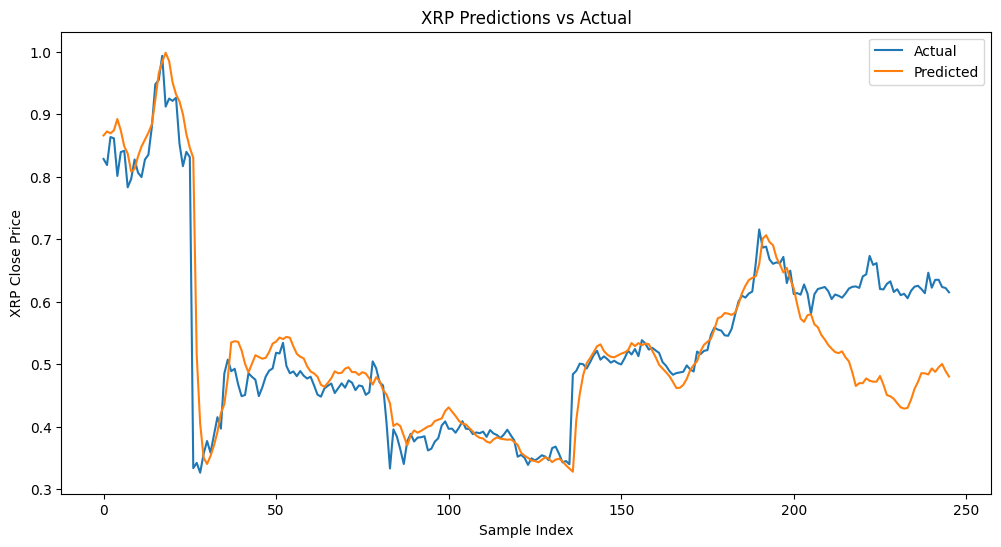

In [143]:
# Plot
plt.figure(figsize=(12,6))
plt.plot(df_xrp_plot_year["Actual"], label="Actual")
plt.plot(df_xrp_plot_year["Predicted"], label="Predicted")
plt.xlabel("Sample Index")
plt.ylabel("XRP Close Price")
plt.title("XRP Predictions vs Actual")
plt.legend()
plt.show()

## Three quaters split model training

In [144]:
# 75% train / 25% test split (time-based)
q3_split_idx = int(len(xrp_X) * 0.75)

xrp_q3_X_train = xrp_X.iloc[:q3_split_idx].values
xrp_q3_X_test  = xrp_X.iloc[q3_split_idx:].values

xrp_q3_y_train = xrp_y.iloc[:q3_split_idx].values
xrp_q3_y_test  = xrp_y.iloc[q3_split_idx:].values

# Shape checks
print("Q3 XRP X_train shape:", xrp_q3_X_train.shape)
print("Q3 XRP X_test shape:", xrp_q3_X_test.shape)
print("Q3 XRP y_train shape:", xrp_q3_y_train.shape)
print("Q3 XRP y_test shape:", xrp_q3_y_test.shape)

Q3 XRP X_train shape: (686, 29)
Q3 XRP X_test shape: (229, 29)
Q3 XRP y_train shape: (686,)
Q3 XRP y_test shape: (229,)


In [145]:
# Assuming xrp_df has Date as index
xrp_q3_test_dates = xrp_df.index[-len(xrp_q3_X_test):]

print("Q3 test dates length:", len(xrp_q3_test_dates))

Q3 test dates length: 229


In [146]:
from sklearn.preprocessing import MinMaxScaler

# Feature scaler
xrp_q3_X_scaler = MinMaxScaler()

# Fit on TRAIN only
xrp_q3_X_train_scaled = xrp_q3_X_scaler.fit_transform(xrp_q3_X_train)

# Transform TEST using same scaler
xrp_q3_X_test_scaled = xrp_q3_X_scaler.transform(xrp_q3_X_test)

print("Q3 Scaled X_train shape:", xrp_q3_X_train_scaled.shape)
print("Q3 Scaled X_test shape:", xrp_q3_X_test_scaled.shape)

Q3 Scaled X_train shape: (686, 29)
Q3 Scaled X_test shape: (229, 29)


In [147]:
# Target scaler
xrp_q3_y_scaler = MinMaxScaler()

# Scale training target
xrp_q3_y_train_scaled = xrp_q3_y_scaler.fit_transform(
    xrp_q3_y_train.reshape(-1, 1)
).flatten()

# Scale test target
xrp_q3_y_test_scaled = xrp_q3_y_scaler.transform(
    xrp_q3_y_test.reshape(-1, 1)
).flatten()

print("Q3 Scaled y_train shape:", xrp_q3_y_train_scaled.shape)
print("Q3 Scaled y_test shape:", xrp_q3_y_test_scaled.shape)

Q3 Scaled y_train shape: (686,)
Q3 Scaled y_test shape: (229,)


In [148]:
import numpy as np

def create_sequences_q3(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i + time_steps])
        y_seq.append(y[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

In [149]:
# Create sequences (30-day window) for XRP
xrp_q3_X_train_seq, xrp_q3_y_train_seq = create_sequences_q3(
    xrp_q3_X_train_scaled,
    xrp_q3_y_train_scaled,
    time_steps=30
)

xrp_q3_X_test_seq, xrp_q3_y_test_seq = create_sequences_q3(
    xrp_q3_X_test_scaled,
    xrp_q3_y_test_scaled,
    time_steps=30
)

# Final shape checks
print("Q3 XRP X_train_seq shape:", xrp_q3_X_train_seq.shape)
print("Q3 XRP y_train_seq shape:", xrp_q3_y_train_seq.shape)
print("Q3 XRP X_test_seq shape:", xrp_q3_X_test_seq.shape)
print("Q3 XRP y_test_seq shape:", xrp_q3_y_test_seq.shape)

Q3 XRP X_train_seq shape: (656, 30, 29)
Q3 XRP y_train_seq shape: (656,)
Q3 XRP X_test_seq shape: (199, 30, 29)
Q3 XRP y_test_seq shape: (199,)


### Model training

In [150]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [151]:
# Get number of features
xrp_q3_input_size = xrp_q3_X_train_seq.shape[2]

# Initialize model
xrp_q3_model = BiLSTM(input_size=xrp_q3_input_size)

In [152]:
# Train model
xrp_q3_model = train_model(xrp_q3_model, xrp_q3_X_train_seq, xrp_q3_y_train_seq, epochs=50, batch_size=32, lr=0.001)

Epoch [10/50], Loss: 0.003575
Epoch [20/50], Loss: 0.001430
Epoch [30/50], Loss: 0.003024
Epoch [40/50], Loss: 0.001173
Epoch [50/50], Loss: 0.002581


In [153]:
# Generate predictions
xrp_q3_preds = predict_model(xrp_q3_model, xrp_q3_X_test_seq)

print("Q3 Predictions shape:", xrp_q3_preds.shape)
print("First 10 Q3 predictions:", xrp_q3_preds[:10])

Q3 Predictions shape: (199, 1)
First 10 Q3 predictions: [[0.15201145]
 [0.15286805]
 [0.15698567]
 [0.16391784]
 [0.16796494]
 [0.16952503]
 [0.16948006]
 [0.16874558]
 [0.16371956]
 [0.15741459]]


In [154]:

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict using the Q3 trained model
xrp_q3_preds_eval = predict_model(xrp_q3_model, xrp_q3_X_test_seq)

# Inverse scale predictions to original price values
xrp_q3_preds_actual = xrp_q3_y_scaler.inverse_transform(
    xrp_q3_preds_eval.reshape(-1, 1)
)

# Inverse scale the test targets
xrp_q3_y_test_actual = xrp_q3_y_scaler.inverse_transform(
    xrp_q3_y_test_seq.reshape(-1, 1)
)

# Calculate metrics
xrp_q3_mse = mean_squared_error(xrp_q3_y_test_actual, xrp_q3_preds_actual)
xrp_q3_rmse = np.sqrt(xrp_q3_mse)
xrp_q3_mae = mean_absolute_error(xrp_q3_y_test_actual, xrp_q3_preds_actual)
xrp_q3_r2 = r2_score(xrp_q3_y_test_actual, xrp_q3_preds_actual)
xrp_q3_mape = np.mean(np.abs((xrp_q3_y_test_actual - xrp_q3_preds_actual) / xrp_q3_y_test_actual)) * 100

# Print results
print(f"Q3 MSE: {xrp_q3_mse:.2f}")
print(f"Q3 RMSE: {xrp_q3_rmse:.2f}")
print(f"Q3 MAE: {xrp_q3_mae:.2f}")
print(f"Q3 R2 Score: {xrp_q3_r2:.4f}")
print(f"Q3 MAPE: {xrp_q3_mape:.2f}%")

Q3 MSE: 0.01
Q3 RMSE: 0.08
Q3 MAE: 0.05
Q3 R2 Score: 0.1297
Q3 MAPE: 8.27%


In [155]:
# Inverse scale predictions
xrp_q3_preds_actual = xrp_q3_y_scaler.inverse_transform(
    xrp_q3_preds.reshape(-1, 1)
)

In [156]:
import pandas as pd
import matplotlib.pyplot as plt

# Align dates and values for XRP Q3 predictions
xrp_q3_dates_seq = xrp_df.index[-len(xrp_q3_X_test):][30:]
xrp_q3_actual_seq = xrp_q3_y_test[30:]
xrp_q3_pred_seq = xrp_q3_preds_actual.flatten()

# Create DataFrame
xrp_q3_df_plot = pd.DataFrame({
    "Date": xrp_q3_dates_seq,
    "Actual": xrp_q3_actual_seq,
    "Predicted": xrp_q3_pred_seq
})

xrp_q3_df_plot.set_index("Date", inplace=True)
xrp_q3_df_plot

,Actual,Predicted
Date,,
2023-06-17,0.479790,0.472463
2023-06-18,0.487573,0.473390
2023-06-19,0.493395,0.477842
2023-06-20,0.492870,0.485338
2023-06-21,0.500695,0.489714
...,...,...
2023-12-28,0.634998,0.509742
2023-12-29,0.623402,0.510206
2023-12-30,0.621844,0.512435


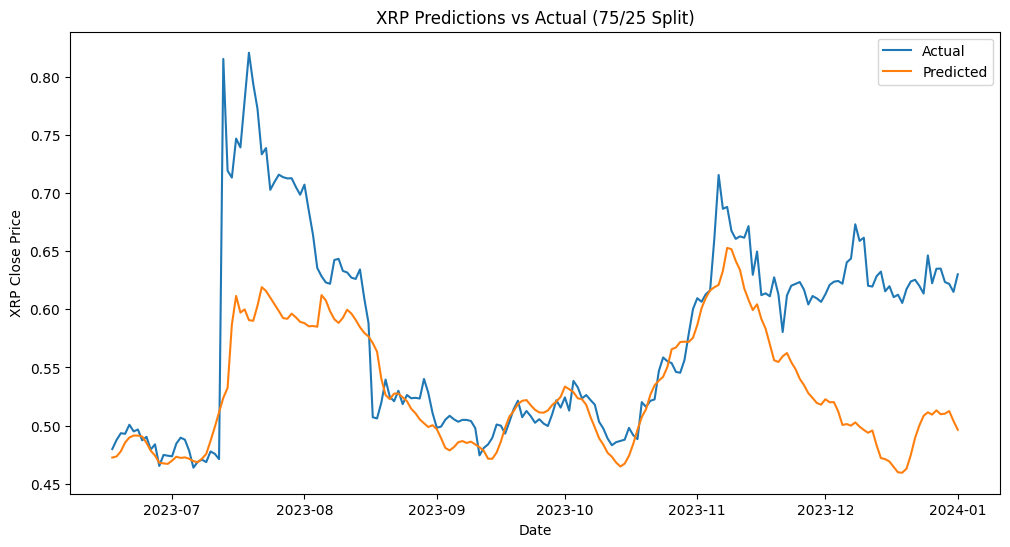

In [157]:
plt.figure(figsize=(12, 6))
plt.plot(xrp_q3_df_plot["Actual"], label="Actual")
plt.plot(xrp_q3_df_plot["Predicted"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("XRP Close Price")
plt.title("XRP Predictions vs Actual (75/25 Split)")
plt.legend()
plt.show()

## Saving the best model (out of accuracy) for Ripple

In [158]:
# import joblib
# joblib.dump(model_y, "Ripple_base_model.pkl")

# Finetuning the models

In [159]:
import optuna

# tuning model_y

In [160]:
from sklearn.model_selection import train_test_split

X_train_tune, X_val_tune, y_train_tune, y_val_tune = train_test_split(
    X_train_seq,
    y_train_seq,
    test_size=0.2,
    shuffle=False
)

In [161]:
import torch
import numpy as np

def objective(trial):

    # Hyperparameters to tune
    hidden_size = trial.suggest_int("hidden_size", 32, 128)
    num_layers = trial.suggest_int("num_layers", 1, 3)
    lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    # Get input size
    input_size = X_train_tune.shape[2]

    # Create model
    model = BiLSTM(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers
    )

    # Train model
    model = train_model(
        model,
        X_train_tune,
        y_train_tune,
        epochs=30,
        batch_size=batch_size,
        lr=lr
    )

    # Validation prediction
    preds = predict_model(model, X_val_tune)

    # Calculate validation MSE
    val_loss = np.mean((preds.flatten() - y_val_tune) ** 2)

    return val_loss

In [162]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)

[I 2026-03-17 14:10:12,317] A new study created in memory with name: no-name-73ab5ca2-4516-4fda-8ec8-4c0b9a383547
C:\Users\tharu\AppData\Local\Temp\ipykernel_14856\3165717294.py:9: FutureWarning:

suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.



Epoch [10/30], Loss: 0.004055
Epoch [20/30], Loss: 0.002100


[I 2026-03-17 14:10:25,197] Trial 0 finished with value: 0.0013691140049714645 and parameters: {'hidden_size': 54, 'num_layers': 2, 'lr': 0.0027042198413882845, 'batch_size': 64}. Best is trial 0 with value: 0.0013691140049714645.


Epoch [30/30], Loss: 0.001469
Epoch [10/30], Loss: 0.024489
Epoch [20/30], Loss: 0.010144


[I 2026-03-17 14:11:20,043] Trial 1 finished with value: 0.0031946425452757535 and parameters: {'hidden_size': 115, 'num_layers': 3, 'lr': 0.00021920398522320367, 'batch_size': 32}. Best is trial 0 with value: 0.0013691140049714645.


...

Epoch [30/30], Loss: 0.004671
Epoch [10/30], Loss: 0.005196
Epoch [20/30], Loss: 0.003579


[I 2026-03-17 14:13:55,918] Trial 8 finished with value: 0.0045894621246512024 and parameters: {'hidden_size': 86, 'num_layers': 2, 'lr': 0.00023303553566981908, 'batch_size': 64}. Best is trial 0 with value: 0.0013691140049714645.


Epoch [30/30], Loss: 0.002562
Epoch [10/30], Loss: 0.016170
Epoch [20/30], Loss: 0.009637


[I 2026-03-17 14:14:09,568] Trial 9 finished with value: 0.0061254651769304 and parameters: {'hidden_size': 41, 'num_layers': 2, 'lr': 0.0031831420227165464, 'batch_size': 32}. Best is trial 0 with value: 0.0013691140049714645.


Epoch [30/30], Loss: 0.008311


In [163]:
print(study.best_params)

{'hidden_size': 54, 'num_layers': 2, 'lr': 0.0027042198413882845, 'batch_size': 64}


In [164]:
import optuna.visualization as vis

In [165]:
vis.plot_optimization_history(study)

In [166]:
vis.plot_param_importances(study)

In [167]:
vis.plot_parallel_coordinate(study)

# Testing new parameters

In [168]:
# Best parameters from Optuna
best_params = study.best_params

# Get input size
input_size = X_train_seq.shape[2]

# Create final tuned model
model_tuned = BiLSTM(
    input_size=input_size,
    hidden_size=best_params["hidden_size"],
    num_layers=best_params["num_layers"]
)

# Train final model on full training data
model_tuned = train_model(
    model_tuned,
    X_train_seq,
    y_train_seq,
    epochs=50,
    batch_size=best_params["batch_size"],
    lr=best_params["lr"]
)

Epoch [10/50], Loss: 0.003368
Epoch [20/50], Loss: 0.003073
Epoch [30/50], Loss: 0.006973
Epoch [40/50], Loss: 0.003211
Epoch [50/50], Loss: 0.003778


In [169]:
xrp_preds_tuned = predict_model(model_tuned, X_test_seq)
xrp_preds_tuned[:10]

array([[0.6237952 ],
       [0.6276749 ],
       [0.62284505],
       [0.625503  ],
       [0.64511925],
       [0.622483  ],
       [0.5932271 ],
       [0.5855364 ],
       [0.5666886 ],
       [0.5684115 ]], dtype=float32)

In [170]:
xrp_preds_tuned_actual = y_scaler.inverse_transform(xrp_preds_tuned.reshape(-1,1))

In [171]:
xrp_y_test_actual = y_scaler.inverse_transform(y_test_seq.reshape(-1,1))

In [172]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(xrp_y_test_actual, xrp_preds_tuned_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(xrp_y_test_actual, xrp_preds_tuned_actual)
r2 = r2_score(xrp_y_test_actual, xrp_preds_tuned_actual)
mape = np.mean(np.abs((xrp_y_test_actual - xrp_preds_tuned_actual) / xrp_y_test_actual)) * 100

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MSE: 0.01
RMSE: 0.08
MAE: 0.06
R2 Score: 0.6763
MAPE: 11.19%


# Saving the best performed model

In [174]:
torch.save(model_y, "XRP_final_model.pth")